# 01 - Dasar Fuzzy dan Fuzzifikasi

In [1]:
# Standard setup cell - run before other cells.
import importlib.util
import subprocess
import sys
from pathlib import Path

def ensure_dependencies():
    """Install only packages used by this module."""
    required = {"numpy": "numpy", "matplotlib": "matplotlib", "pandas": "pandas"}
    missing = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_module_dir(start):
    """Find the shared membership module."""
    for root in [start, *start.parents]:
        for candidate in (root, root / "Fuzzy Logic"):
            if (candidate / "membership.py").exists():
                return candidate
        if (root / ".git").exists():
            break
    return None

ensure_dependencies()
module_dir = find_module_dir(Path.cwd())

if module_dir is None and "google.colab" in sys.modules:
    clone_dir = Path("Modul-Praktikum-KK-RKA-25")
    if not clone_dir.exists():
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/kcv-if/Modul-Praktikum-KK-RKA-25.git", str(clone_dir)], check=True)
    module_dir = find_module_dir(clone_dir)

if module_dir is None:
    # Fallback jika membership.py dibuat di folder lokal yang sama
    module_dir = Path.cwd()

if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from membership import linear_up, linear_down, triangular, trapezoidal, sigmoid, phi

print("Python:", sys.version.split()[0])
print("Membership module:", module_dir / "membership.py")

Python: 3.12.4
Membership module: c:\Users\LEGION\Praktikum-KK\fuzzy-logic\membership.py


# Soal 1 - Pemahaman Konsep

## 1. Arti Derajat Keanggotaan x = 3.5 m

* derajat dekat = 0.25: nilai ini nunjukin kalo jarak 3.5 meter tuh punya tingkat kesesuaian/kecocokan 25% atau 0.25 ke label linguistik dekat. melht dr grafik linear_down(x, 2, 4) titik x = 3.5 m ada di posisi transisi turun dr rentang a = 2 m sampe b = 4 m. jd pas ditarik garis vertikal di x = 3.5 dia bakal motong kurva dekat di ketinggian y = 0.25
* derajat sedang ≈ 0.8333: artinya kecocokan jarak 3.5 meter ke kategori sedang tuh lumayan tinggi kek di angka 83.33%. di fungsi trapesium trapezoidal(x, 1, 4, 6, 9) posisi x = 3.5 m lg ada di fase transisi naik dr a = 1 m menuju daerah penuh di b = 4 m makanya pas dipotong garis vertikal ketemu titiknya di y ≈ 0.8333 mendekati puncaknya

## 2. Tanggapan Soal Total Derajat Melebihi 1

gak setuju

alasan dr definisi fungsi keanggotaan:
di fuzzy logic tiap membership function menilai kecocokan input secara independent / mandiri ke masing2 label. fungsi keanggotaan cuma memetakan nilai masukan crisp ke rentang 0 sampe 1 buat label itu doang. sistem gak pernah ngeharusin total penjumlahnn derajat keanggotaan antar label harus 1 jd mau totalnya 0.25 + 0.8333 = 1.0833 itu tetep sah dan bener secara konsep karena ini kan bukan membagi porsi probabilitas

## 3. Komparasi Derajat Fuzzy vs Peluang (Probabilitas)

* derajat dekat adalah 0.25: ngedijelasin soal vagueness / ketidaktegasan yaitu seberapa cocok nilai crisp yg udah pasti terukur (3.5 m) sm definisi linguistik dekat. angkanya menilai kecocokan konsep/kategori bukan ketidakpastian
* peluang jarak kurang dr 3 m adalah 25%: ngedijelasin uncertainty / ketidakpastian kejadian dr sekumpulan data atau eksperimen statistik. angkanya nunjukin seberapa sering atau besar chance suatu pengukuran jarak nilainya beneran jatuh di bawah 3 meter

# SOAL 2 - FUZZIFIKASI & AKTIVASI ATURAN

## 1. Penentuan Cabang Rumus dan Perhitungan Manual
ambil titik sampel jarak x = 1.0, 2.5, 3.5, 5.0, 7.0, dan 8.5 meter melht dr seluruh wilayah domain fungsi
- x = 1.0 m
  dekat: x <= 2 -> cabang datar penuh -> mu = 1.0
  sedang: x <= 1 -> cabang nol -> mu = 0.0
  jauh: x <= 6 -> cabang nol -> mu = 0.0
  aturan aktif: R1 = 1.0 (kecepatan rendah)

- x = 2.5 m
  dekat: 2 < x < 4 -> cabang transisi turun (4 - 2.5) / (4 - 2) = 1.5 / 2 -> mu = 0.75
  sedang: 1 < x < 4 -> cabang transisi naik (2.5 - 1) / (4 - 1) = 1.5 / 3 -> mu = 0.5
  jauh: x <= 6 -> cabang nol -> mu = 0.0
  aturan aktif: R1 = 0.75 (kecepatan rendah) dan R2 = 0.5 (kecepatan sedang)

- x = 3.5 m
  dekat: 2 < x < 4 -> cabang transisi turun (4 - 3.5) / (4 - 2) = 0.5 / 2 -> mu = 0.25
  sedang: 1 < x < 4 -> cabang transisi naik (3.5 - 1) / (4 - 1) = 2.5 / 3 -> mu ≈ 0.8333
  jauh: x <= 6 -> cabang nol -> mu = 0.0
  aturan aktif: R1 = 0.25 (kecepatan rendah) dan R2 = 0.8333 (kecepatan sedang)

- x = 5.0 m
  dekat: x >= 4 -> cabang nol -> mu = 0.0
  sedang: 4 <= x <= 6 -> cabang datar penuh -> mu = 1.0
  jauh: x <= 6 -> cabang nol -> mu = 0.0
  aturan aktif: R2 = 1.0 (kecepatan sedang)

- x = 7.0 m
  dekat: x >= 4 -> cabang nol -> mu = 0.0
  sedang: 6 < x < 9 -> cabang transisi turun (9 - 7) / (9 - 6) = 2 / 3 -> mu ≈ 0.6667
  jauh: 6 < x < 8 -> cabang transisi naik (7 - 6) / (8 - 6) = 1 / 2 -> mu = 0.5
  aturan aktif: R2 = 0.6667 (kecepatan sedang) dan R3 = 0.5 (kecepatan tinggi)

- x = 8.5 m
  dekat: x >= 4 -> cabang nol -> mu = 0.0
  sedang: 6 < x < 9 -> cabang transisi turun (9 - 8.5) / (9 - 6) = 0.5 / 3 -> mu ≈ 0.1667
  jauh: x >= 8 -> cabang datar penuh -> mu = 1.0
  aturan aktif: R2 = 0.1667 (kecepatan sedang) dan R3 = 1.0 (kecepatan tinggi)

## 2. Tabel Markdown Hasil Fuzzifikasi & Aktivasi Aturan

| Jarak (m) | Derajat Dekat | Derajat Sedang | Derajat Jauh | Aturan Aktif & Firing Strength |
| --- | --- | --- | --- | --- |
| 1.0 | 1.0000 | 0.0000 | 0.0000 | R1 = 1.0000 |
| 2.5 | 0.7500 | 0.5000 | 0.0000 | R1 = 0.7500, R2 = 0.5000 |
| 3.5 | 0.2500 | 0.8333 | 0.0000 | R1 = 0.2500, R2 = 0.8333 |
| 5.0 | 0.0000 | 1.0000 | 0.0000 | R2 = 1.0000 |
| 7.0 | 0.0000 | 0.6667 | 0.5000 | R2 = 0.6667, R3 = 0.5000 |
| 8.5 | 0.0000 | 0.1667 | 1.0000 | R2 = 0.1667, R3 = 1.0000 |

In [2]:
# Verifikasi fungsi fuzzify_distance & pembuatan tabel otomatis
def fuzzify_distance(distance):
    if not np.isfinite(distance) or not 0 <= distance <= 10:
        raise ValueError("Jarak harus berada pada domain 0-10 meter.")
    return {
        "dekat": linear_down(distance, 2, 4),
        "sedang": trapezoidal(distance, 1, 4, 6, 9),
        "jauh": linear_up(distance, 6, 8),
    }

sample_distances = [1.0, 2.5, 3.5, 5.0, 7.0, 8.5]
table_data = []

for d in sample_distances:
    mu = fuzzify_distance(d)
    r1, r2, r3 = mu["dekat"], mu["sedang"], mu["jauh"]
    rules = [f"R1 = {r1:.4f}" if r1>0 else "", f"R2 = {r2:.4f}" if r2>0 else "", f"R3 = {r3:.4f}" if r3>0 else ""]
    active = ", ".join([r for r in rules if r])
    table_data.append({"jarak (m)": d, "derajat dekat": round(r1, 4), "derajat sedang": round(r2, 4), "derajat jauh": round(r3, 4), "aturan aktif & firing strength": active})

df_soal2 = pd.DataFrame(table_data)
display(df_soal2)

,jarak (m),derajat dekat,derajat sedang,derajat jauh,aturan aktif & firing strength
0,1.0,1.00,0.0000,0.0,R1 = 1.0000
1,2.5,0.75,0.5000,0.0,"R1 = 0.7500, R2 = 0.5000"
2,3.5,0.25,0.8333,0.0,"R1 = 0.2500, R2 = 0.8333"
3,5.0,0.00,1.0000,0.0,R2 = 1.0000
4,7.0,0.00,0.6667,0.5,"R2 = 0.6667, R3 = 0.5000"
5,8.5,0.00,0.1667,1.0,"R2 = 0.1667, R3 = 1.0000"


# SOAL 3 - PENGARUH PERUBAHAN PARAMETER

### 3.1 Prediksi Pengaruh Perubahan Parameter dan Perhitungan Derajat Dekat

sebelum ngitung, perubahan parameter dari linear_down(x, 2, 4) jadi linear_down(x, 2, 5) ini bikin transisi batas dekatnya jadi lebih panjang. titik akhir transisi bakal bergeser dari 4 m ke 5 m

pada jarak 3.5 m (di daerah transisi 2 sampe b), fungsi baru ini punya kemiringan garis yang lebih landai jadi, derajat dekat pas x = 3.5 m diprediksi bakal nambah / naik

Alasan matematis:
mu_dekat = (b - x) / (b - a)

karna nilai b nya makin gede, pembilang (b - x) ama penyebut (b - a) bakal makin meningkat, jadinya nilai mu_dekat bakal kerasa lebih besar nilainya

In [3]:
# hitung derajat dekat lama dan baru serta aktivasi R1
x = 3.5

# fungsi lama: a=2, b=4
mu_dekat_lama = linear_down(x, 2, 4)

# fungsi baru: a=2, b=5
mu_dekat_baru = linear_down(x, 2, 5)

# kekuatan aktivasi R1 (misal R1 bergantung pada derajat dekat)
R1_lama = mu_dekat_lama
R1_baru = mu_dekat_baru

print(f"derajat dekat lama (2,4) : {mu_dekat_lama:.4f}")
print(f"derajat dekat baru (2,5) : {mu_dekat_baru:.4f}")
print(f"kekuatan R1 lama          : {R1_lama:.4f}")
print(f"kekuatan R1 baru          : {R1_baru:.4f}")

derajat dekat lama (2,4) : 0.2500
derajat dekat baru (2,5) : 0.5000
kekuatan R1 lama          : 0.2500
kekuatan R1 baru          : 0.5000


| Parameter | Nilai b | mu_dekat(3.5) | Kekuatan R1 |
|---|---|---|---|
| Lama | 4 | 0.2500 | 0.2500 |
| Baru | 5 | 0.5000 | 0.5000 |

keliatan kekuatan aktivasi R1 nya ngalamin peningkatan dari 0.2500 jadi 0.5000 pas dicoba dihitung

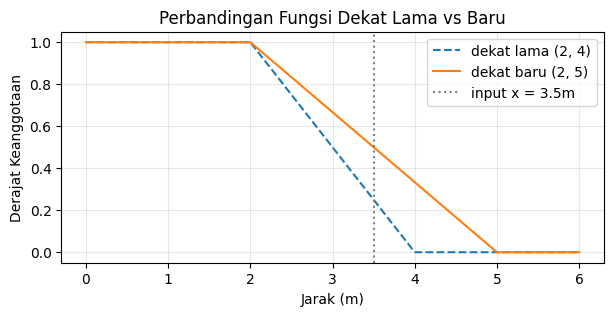

In [4]:
# plot kedua fungsi dekat pada domain 0-6 m
domain = np.linspace(0, 6, 600)

y_lama = [linear_down(d, 2, 4) for d in domain]
y_baru = [linear_down(d, 2, 5) for d in domain]

plt.figure(figsize=(7, 3))
plt.plot(domain, y_lama, label="dekat lama (2, 4)", linestyle="--")
plt.plot(domain, y_baru, label="dekat baru (2, 5)")
plt.axvline(3.5, color="gray", linestyle=":", label="input x = 3.5m")

plt.title("Perbandingan Fungsi Dekat Lama vs Baru")
plt.xlabel("Jarak (m)")
plt.ylabel("Derajat Keanggotaan")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### identifikasi Domain
domain terbagi jadi 3 bagian utama kek gini:

domain tetep sama (x <= 2 m):
nilai mu_dekat bakalan tetep 1 di kedua kurvanya.

domain berubah (2 m < x < 5 m):
garis transisi turun ngalamin shift / pergeseran kemiringan. kurva baru miliki nilai keanggotaan lebih tinggi dibanding kurva lama.

domain tetep sama (x >= 5 m):
nilai mu_dekat = 0 buat kedua kurva ini.

### 3.2 Penentuan Kecepatan Akhir

perubahan kekuatan aktivasi R1 doang sbenernya gak langsung cukup buat nentuin angka pasti kecepatan akhirnya.

ada bbrapa step dan info di FIS yang masih perlu di-check:

evaluasi aturan lain (R2, R3, dll):
perlu diliat apa variabl sedang atau jauh ikut aktif di jarak 3.5 m ini dan seberapa gedde nilai aktivasinya.

implikasi / firing strength:
proses evaluasi hasil pemotongan / pemetaan tiap rule ke himpunan fuzzy output (kecepatan).

agregasi aturan:
nggabungin seluruh daerah hasil implikasi rule biar dapet satu daerah fuzzy output gabungan.

defuzzifikasi:
proses convert dari himpunan fuzzy gabungan tadi biar dapet crisp value buat kecepatan akhir, misal make method Centroid